In [1]:
import os
import numpy as np
from PIL import Image
from tqdm import tqdm

INPUT_DIR = r"D:\\cells\\HEP2\\HEP2_tif\\24"
OUTPUT_DIR = r"D:\\cells\\HEP2\\HEP2_png\\24"
CONVERT_TO_GRAYSCALE = True
NORMALIZE_16BIT = True

os.makedirs(OUTPUT_DIR, exist_ok=True)

def normalize_to_8bit(img_array):

    img_array = img_array.astype(np.float32)

    min_val = np.min(img_array)
    max_val = np.max(img_array)

    if max_val - min_val == 0:
        return np.zeros_like(img_array, dtype=np.uint8)

    img_array = (img_array - min_val) / (max_val - min_val)
    img_array = (img_array * 255).clip(0, 255)

    return img_array.astype(np.uint8)

tiff_files = [f for f in os.listdir(INPUT_DIR) if f.lower().endswith((".tif", ".tiff"))]

print(f"Найдено файлов: {len(tiff_files)}")

for filename in tqdm(tiff_files):
    input_path = os.path.join(INPUT_DIR, filename)
    output_name = os.path.splitext(filename)[0] + ".png"
    output_path = os.path.join(OUTPUT_DIR, output_name)

    with Image.open(input_path) as img:

        img_array = np.array(img)

        if CONVERT_TO_GRAYSCALE and len(img_array.shape) == 3:
            img_array = np.mean(img_array, axis=2)

        if NORMALIZE_16BIT and img_array.dtype != np.uint8:
            img_array = normalize_to_8bit(img_array)

        img_out = Image.fromarray(img_array)
        img_out.save(output_path, format="PNG")

print("Готово.")

Найдено файлов: 155


100%|██████████| 155/155 [10:10<00:00,  3.94s/it]

Готово.


In [5]:
from pathlib import Path
import random
import shutil

SRC_ROOT = Path(r"D:\\cells\\HEP2\\HEP2_png")   
DST_ROOT = Path(r"D:\\cells\\dataset_HEP2_RSV")  
CLASSES = ["24", "48", "72", "healthy"]

SEED = 42
TRAIN_FRAC = 0.70
VAL_FRAC   = 0.15
TEST_FRAC  = 0.15

MIN_VAL_PER_CLASS = 10
MIN_TEST_PER_CLASS = 10


random.seed(SEED)

def list_pngs(class_dir: Path):
    return sorted([p for p in class_dir.rglob("*.png") if p.is_file()])

def ensure_dirs():
    for split in ["train", "val", "test"]:
        for c in CLASSES:
            (DST_ROOT / split / c).mkdir(parents=True, exist_ok=True)

def split_counts(n: int):
    n_val = max(int(round(n * VAL_FRAC)), MIN_VAL_PER_CLASS)
    n_test = max(int(round(n * TEST_FRAC)), MIN_TEST_PER_CLASS)

    if n_val + n_test >= n:
        n_val = min(n_val, n - 2)
        n_test = min(n_test, n - 1 - n_val)

    n_train = n - n_val - n_test
    return n_train, n_val, n_test

def copy_files(files, out_dir: Path):
    out_dir.mkdir(parents=True, exist_ok=True)
    for src in files:
        dst = out_dir / src.name
        if not dst.exists():
            shutil.copy2(src, dst)

missing = [c for c in CLASSES if not (SRC_ROOT / c).is_dir()]
if missing:
    raise SystemExit(f"Не найдены папки классов в {SRC_ROOT}: {missing}")

ensure_dirs()

summary = {}

for c in CLASSES:
    files = list_pngs(SRC_ROOT / c)
    n = len(files)
    if n == 0:
        raise SystemExit(f"Класс {c} пустой")

    random.shuffle(files)
    n_train, n_val, n_test = split_counts(n)

    val_files = files[:n_val]
    test_files = files[n_val:n_val + n_test]
    train_files = files[n_val + n_test:]

    copy_files(train_files, DST_ROOT / "train" / c)
    copy_files(val_files,   DST_ROOT / "val"   / c)
    copy_files(test_files,  DST_ROOT / "test"  / c)

    summary[c] = {"train": len(train_files), "val": len(val_files), "test": len(test_files), "total": n}

print(f"SRC_ROOT = {SRC_ROOT.resolve()}")
print(f"DST_ROOT = {DST_ROOT.resolve()}\n")

print("Распределение по классам:")
tot_train = tot_val = tot_test = tot_all = 0
for c in CLASSES:
    s = summary[c]
    print(f"  {c:>7}: train={s['train']:>3}  val={s['val']:>3}  test={s['test']:>3}  total={s['total']}")
    tot_train += s["train"]
    tot_val   += s["val"]
    tot_test  += s["test"]
    tot_all   += s["total"]

print("\nИТОГО:")
print(f"  train={tot_train}  val={tot_val}  test={tot_test}  total={tot_all}")

SRC_ROOT = D:\cells\HEP2\HEP2_png
DST_ROOT = D:\cells\dataset_HEP2_RSV

Распределение по классам:
       24: train=109  val= 23  test= 23  total=155
       48: train= 90  val= 20  test= 20  total=130
       72: train= 59  val= 12  test= 12  total=83
  healthy: train=239  val= 51  test= 51  total=341

ИТОГО:
  train=497  val=106  test=106  total=709


In [43]:
from pathlib import Path
from collections import Counter
import numpy as np
import tensorflow as tf

DATA_ROOT = Path(r"dataset_HEP2_RSV")
CLASS_NAMES = ["24", "48", "72", "healthy"]
CLASS_TO_IDX = {name: i for i, name in enumerate(CLASS_NAMES)}

MODEL_SIZE = 512          # размер входа модели
RAW_PATCH_SIZE = 1024     # patch из исходного изображения
BATCH_SIZE = 8           # на CPU лучше 2-4
SEED = 42
AUTOTUNE = tf.data.AUTOTUNE

tf.random.set_seed(SEED)

def collect_split(split_name):
    split_root = DATA_ROOT / split_name
    paths, labels = [], []

    for cls_name in CLASS_NAMES:
        class_dir = split_root / cls_name
        if not class_dir.exists():
            raise FileNotFoundError(f"Не найдена папка: {class_dir}")

        for ext in ("*.png", "*.jpg", "*.jpeg"):
            for p in sorted(class_dir.glob(ext)):
                paths.append(str(p))
                labels.append(CLASS_TO_IDX[cls_name])

    return paths, labels


train_paths, train_labels = collect_split("train")
val_paths, val_labels = collect_split("val")
test_paths, test_labels = collect_split("test")

print("train:", len(train_paths))
print("val:  ", len(val_paths))
print("test: ", len(test_paths))


train: 497
val:   106
test:  106


In [44]:
def read_image(path):
    # Считываем как grayscale, потом дублируем в 3 канала
    img = tf.io.read_file(path)
    img = tf.io.decode_png(img, channels=1)  # [H, W, 1]
    img = tf.image.grayscale_to_rgb(img)     # [H, W, 3]
    img = tf.cast(img, tf.float32)           # оставляем диапазон 0..255
    return img


def pad_to_min_size(img, min_size):
    h = tf.shape(img)[0]
    w = tf.shape(img)[1]

    pad_h = tf.maximum(0, min_size - h)
    pad_w = tf.maximum(0, min_size - w)

    img = tf.pad(
        img,
        paddings=[
            [pad_h // 2, pad_h - pad_h // 2],
            [pad_w // 2, pad_w - pad_w // 2],
            [0, 0]
        ],
        mode="REFLECT"
    )
    return img


def random_patch_from_fullres(img):
    img = pad_to_min_size(img, RAW_PATCH_SIZE)
    img = tf.image.random_crop(img, size=[RAW_PATCH_SIZE, RAW_PATCH_SIZE, 3])
    img = tf.image.resize(img, [MODEL_SIZE, MODEL_SIZE], method="bilinear")
    return img


def center_patch_from_fullres(img):
    img = pad_to_min_size(img, RAW_PATCH_SIZE)

    h = tf.shape(img)[0]
    w = tf.shape(img)[1]

    offset_h = (h - RAW_PATCH_SIZE) // 2
    offset_w = (w - RAW_PATCH_SIZE) // 2

    img = tf.image.crop_to_bounding_box(
        img,
        offset_h,
        offset_w,
        RAW_PATCH_SIZE,
        RAW_PATCH_SIZE
    )
    img = tf.image.resize(img, [MODEL_SIZE, MODEL_SIZE], method="bilinear")
    return img


def preprocess_train(path, label):
    img = read_image(path)
    img = random_patch_from_fullres(img)
    return img, label


def preprocess_eval(path, label):
    img = read_image(path)
    img = center_patch_from_fullres(img)
    return img, label

In [45]:
def make_dataset(paths, labels, training):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if training:
        ds = ds.shuffle(len(paths), seed=SEED, reshuffle_each_iteration=True)
        ds = ds.map(preprocess_train, num_parallel_calls=AUTOTUNE)
    else:
        ds = ds.map(preprocess_eval, num_parallel_calls=AUTOTUNE)

    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds


train_ds = make_dataset(train_paths, train_labels, training=True)
val_ds = make_dataset(val_paths, val_labels, training=False)
test_ds = make_dataset(test_paths, test_labels, training=False)

In [46]:
counts = Counter(train_labels)
num_classes = len(CLASS_NAMES)
total = len(train_labels)

class_weight = {
    cls_idx: total / (num_classes * count)
    for cls_idx, count in counts.items()
}

print("train class counts:", counts)
print("class_weight:", class_weight)

train class counts: Counter({3: 239, 0: 109, 1: 90, 2: 59})
class_weight: {0: 1.139908256880734, 1: 1.3805555555555555, 2: 2.1059322033898304, 3: 0.5198744769874477}


In [47]:
class SparseMacroF1(tf.keras.metrics.Metric):
    def __init__(self, num_classes, name="macro_f1", **kwargs):
        super().__init__(name=name, **kwargs)
        self.num_classes = num_classes
        self.cm = self.add_weight(
            name="conf_matrix",
            shape=(num_classes, num_classes),
            initializer="zeros",
            dtype=tf.float32
        )

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.reshape(tf.cast(y_true, tf.int32), [-1])
        y_pred = tf.argmax(y_pred, axis=-1, output_type=tf.int32)

        cm_batch = tf.math.confusion_matrix(
            y_true,
            y_pred,
            num_classes=self.num_classes,
            dtype=tf.float32
        )
        self.cm.assign_add(cm_batch)

    def result(self):
        tp = tf.linalg.diag_part(self.cm)
        fp = tf.reduce_sum(self.cm, axis=0) - tp
        fn = tf.reduce_sum(self.cm, axis=1) - tp

        precision = tf.math.divide_no_nan(tp, tp + fp)
        recall = tf.math.divide_no_nan(tp, tp + fn)
        f1 = tf.math.divide_no_nan(2.0 * precision * recall, precision + recall)

        return tf.reduce_mean(f1)

    def reset_state(self):
        self.cm.assign(tf.zeros_like(self.cm))

In [48]:
from tensorflow.keras import layers, Model

def build_model():
    inputs = tf.keras.Input(shape=(MODEL_SIZE, MODEL_SIZE, 3))

    x = layers.RandomFlip("horizontal_and_vertical")(inputs)
    x = layers.RandomRotation(0.05)(x)
    x = layers.RandomContrast(0.10)(x)

    x = layers.Rescaling(scale=1.0 / 127.5, offset=-1.0)(x)

    base = tf.keras.applications.EfficientNetV2S(
        include_top=False,
        weights="imagenet",
        include_preprocessing=False
    )
    base.trainable = False

    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.30)(x)
    outputs = layers.Dense(len(CLASS_NAMES), activation="softmax")(x)

    model = Model(inputs, outputs)
    return model, base


model, base = build_model()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(name="acc"),
        tf.keras.metrics.SparseTopKCategoricalAccuracy(k=2, name="top2_acc"),
        SparseMacroF1(num_classes=len(CLASS_NAMES), name="macro_f1"),
    ]
)

model.summary()

Model: "functional_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_5 (RandomFlip)      │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_5               │ (None, 512, 512, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast_5               │ (None, 512, 512, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_5 (Rescaling)         │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-s (Functional)   │ (None, 16, 16, 1280)   │    20,331,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,336,484 (77.58 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 20,331,360 (77.56 MB)

In [49]:
callbacks_stage1 = [
    tf.keras.callbacks.ModelCheckpoint(
        "hep2_patch_stage1.keras",
        monitor="val_macro_f1",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_macro_f1",
        mode="max",
        patience=6,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_macro_f1",
        mode="max",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),
]

history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weight,
    callbacks=callbacks_stage1
)

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc: 0.4286 - loss: 1.2822 - macro_f1: 0.3793 - top2_acc: 0.7090
Epoch 1: val_macro_f1 improved from -inf to 0.68319, saving model to hep2_patch_stage1.keras
63/63 ━━━━━━━━━━━━━━━━━━━━ 154s 2s/step - acc: 0.4314 - loss: 1.2784 - macro_f1: 0.3816 - top2_acc: 0.7109 - val_acc: 0.8774 - val_loss: 0.5703 - val_macro_f1: 0.6832 - val_top2_acc: 0.9811 - learning_rate: 0.0010
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc: 0.7688 - loss: 0.7764 - macro_f1: 0.6848 - top2_acc: 0.9555
Epoch 2: val_macro_f1 improved from 0.68319 to 0.79313, saving model to hep2_patch_stage1.keras
63/63 ━━━━━━━━━━━━━━━━━━━━ 135s 2s/step - acc: 0.7694 - loss: 0.7749 - macro_f1: 0.6854 - top2_acc: 0.9556 - val_acc: 0.8962 - val_loss: 0.3830 - val_macro_f1: 0.7931 - val_top2_acc: 0.9906 - learning_rate: 0.0010
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc: 0.8173 - loss: 0.5734 - macro_f1: 0.7364 - top2_acc: 0.9654
Epoch 3: val_macro_f1 improved from

In [50]:
base.trainable = True

for layer in base.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

freeze_until = int(0.65 * len(base.layers))
for layer in base.layers[:freeze_until]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(name="acc"),
        tf.keras.metrics.SparseTopKCategoricalAccuracy(k=2, name="top2_acc"),
        SparseMacroF1(num_classes=len(CLASS_NAMES), name="macro_f1"),
    ]
)

callbacks_stage2 = [
    tf.keras.callbacks.ModelCheckpoint(
        "hep2_patch_finetuned.keras",
        monitor="val_macro_f1",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_macro_f1",
        mode="max",
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_macro_f1",
        mode="max",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),
]

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    class_weight=class_weight,
    callbacks=callbacks_stage2
)

Epoch 1/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc: 0.8891 - loss: 0.3626 - macro_f1: 0.8458 - top2_acc: 0.9936
Epoch 1: val_macro_f1 improved from -inf to 0.84127, saving model to hep2_patch_finetuned.keras
63/63 ━━━━━━━━━━━━━━━━━━━━ 193s 3s/step - acc: 0.8894 - loss: 0.3620 - macro_f1: 0.8460 - top2_acc: 0.9936 - val_acc: 0.9057 - val_loss: 0.1760 - val_macro_f1: 0.8413 - val_top2_acc: 1.0000 - learning_rate: 1.0000e-05
Epoch 2/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc: 0.9199 - loss: 0.2905 - macro_f1: 0.8654 - top2_acc: 0.9964
Epoch 2: val_macro_f1 improved from 0.84127 to 0.88406, saving model to hep2_patch_finetuned.keras
63/63 ━━━━━━━━━━━━━━━━━━━━ 169s 3s/step - acc: 0.9198 - loss: 0.2907 - macro_f1: 0.8655 - top2_acc: 0.9963 - val_acc: 0.9434 - val_loss: 0.1563 - val_macro_f1: 0.8841 - val_top2_acc: 1.0000 - learning_rate: 1.0000e-05
Epoch 3/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc: 0.9190 - loss: 0.2598 - macro_f1: 0.8581 - top2_acc: 0.9988
Epoch 3: val_macro_f1

In [63]:
model = tf.keras.models.load_model(
    "hep2_patch_finetuned.keras",
    compile=False
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(name="acc"),
        tf.keras.metrics.SparseTopKCategoricalAccuracy(k=2, name="top2_acc"),
        SparseMacroF1(num_classes=4, name="macro_f1"),
    ],
)

model.save("hep2_patch_finetuned_fixed.keras")

In [64]:
test_metrics = model.evaluate(test_ds, return_dict=True)
print(test_metrics)

14/14 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - acc: 0.9839 - loss: 0.0937 - macro_f1: 0.7603 - top2_acc: 1.0000
{'acc': 0.9811320900917053, 'loss': 0.09544003009796143, 'macro_f1': 0.9653679728507996, 'top2_acc': 1.0}


In [55]:
from sklearn.metrics import confusion_matrix, classification_report

def five_crops_from_fullres(img):
    img = pad_to_min_size(img, RAW_PATCH_SIZE)

    h = tf.shape(img)[0]
    w = tf.shape(img)[1]

    y0 = 0
    x0 = 0
    y1 = h - RAW_PATCH_SIZE
    x1 = w - RAW_PATCH_SIZE
    yc = (h - RAW_PATCH_SIZE) // 2
    xc = (w - RAW_PATCH_SIZE) // 2

    crops = [
        tf.image.crop_to_bounding_box(img, y0, x0, RAW_PATCH_SIZE, RAW_PATCH_SIZE),  # top-left
        tf.image.crop_to_bounding_box(img, y0, x1, RAW_PATCH_SIZE, RAW_PATCH_SIZE),  # top-right
        tf.image.crop_to_bounding_box(img, y1, x0, RAW_PATCH_SIZE, RAW_PATCH_SIZE),  # bottom-left
        tf.image.crop_to_bounding_box(img, y1, x1, RAW_PATCH_SIZE, RAW_PATCH_SIZE),  # bottom-right
        tf.image.crop_to_bounding_box(img, yc, xc, RAW_PATCH_SIZE, RAW_PATCH_SIZE),  # center
    ]

    crops = [tf.image.resize(c, [MODEL_SIZE, MODEL_SIZE], method="bilinear") for c in crops]
    crops = tf.stack(crops, axis=0)  # [5, 512, 512, 3]
    return crops


def predict_multicrop(image_path):
    img = read_image(image_path)
    crops = five_crops_from_fullres(img)

    probs = model.predict(crops, verbose=0)   # [5, num_classes]
    mean_probs = probs.mean(axis=0)

    pred_idx = int(np.argmax(mean_probs))
    return pred_idx, mean_probs

In [ ]:
y_true = []
y_pred = []

for path, true_label in zip(test_paths, test_labels):
    pred_idx, probs = predict_multicrop(path)
    y_true.append(true_label)
    y_pred.append(pred_idx)

print("Confusion matrix:")
print(confusion_matrix(y_true, y_pred))

print("\nClassification report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

0 0
0 0
0 0
0 0
0 0
0 0
0 0
0 0
0 0
0 0
0 0
0 0
0 0
0 0
0 0
0 0
0 0
0 0


KeyboardInterrupt: 

In [96]:
print(test_paths)

['dataset_HEP2_RSV\\test\\24\\TUC-20251219092749198.png', 'dataset_HEP2_RSV\\test\\24\\TUC-20251219092753031.png', 'dataset_HEP2_RSV\\test\\24\\TUC-20251219092853785.png', 'dataset_HEP2_RSV\\test\\24\\TUC-20251219092915498.png', 'dataset_HEP2_RSV\\test\\24\\TUC-20260204085418080.png', 'dataset_HEP2_RSV\\test\\24\\TUC-20260204085958856.png', 'dataset_HEP2_RSV\\test\\24\\TUC-20260204090451806.png', 'dataset_HEP2_RSV\\test\\24\\TUC-20260204090507957.png', 'dataset_HEP2_RSV\\test\\24\\TUC-20260204090727393.png', 'dataset_HEP2_RSV\\test\\24\\TUC-20260204090835691.png', 'dataset_HEP2_RSV\\test\\24\\TUC-20260204091238642.png', 'dataset_HEP2_RSV\\test\\24\\TUC-20260204091414371.png', 'dataset_HEP2_RSV\\test\\24\\TUC-20260204091448536.png', 'dataset_HEP2_RSV\\test\\24\\TUC-20260204091603488.png', 'dataset_HEP2_RSV\\test\\24\\TUC-20260204091741150.png', 'dataset_HEP2_RSV\\test\\24\\TUC-20260204092027431.png', 'dataset_HEP2_RSV\\test\\24\\TUC-20260204102052200.png', 'dataset_HEP2_RSV\\test\\24\\T

In [67]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input

class_names = ['24', '48', '72', 'healthy']

IMG_SIZE = 512

def predict_single_image(image_path):
    img = tf.keras.utils.load_img(image_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = tf.keras.utils.img_to_array(img)

    img_array = preprocess_input(img_array)

    img_array = np.expand_dims(img_array, axis=0)

    probs = model.predict(img_array, verbose=0)[0]
    pred_index = np.argmax(probs)
    pred_class = class_names[pred_index]
    confidence = probs[pred_index]

    plt.imshow(tf.keras.utils.load_img(image_path))
    plt.title(f"Pred: {pred_class}  ({confidence:.3f})")
    plt.axis("off")
    plt.show()

    print("Probabilities:")
    for i, cls in enumerate(class_names):
        print(f"{cls:8s}: {probs[i]:.4f}")

    return pred_class, confidence

<>:1: SyntaxWarning: invalid escape sequence '\c'
<>:1: SyntaxWarning: invalid escape sequence '\c'
C:\Users\Glush\AppData\Local\Temp\ipykernel_16332\162254028.py:1: SyntaxWarning: invalid escape sequence '\c'
  predict_single_image("D:\cells\dataset_HEP2_RSV\\test\healthy\TUC-20260203082118966.png")


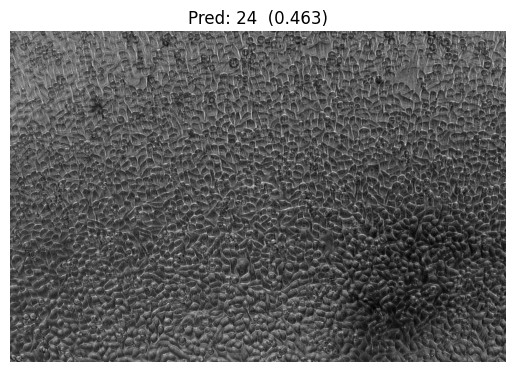

Probabilities:
24      : 0.4632
48      : 0.3678
72      : 0.1124
healthy : 0.0566


('24', 0.46316457)

In [97]:
predict_single_image("D:\cells\dataset_HEP2_RSV\\test\healthy\TUC-20260203082118966.png")